<a href="https://colab.research.google.com/github/juanjararPYBM/ibm-data-science-portfolio/blob/main/Fase3_Data_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


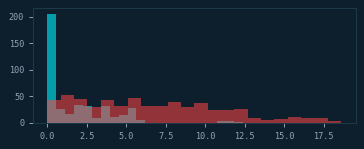
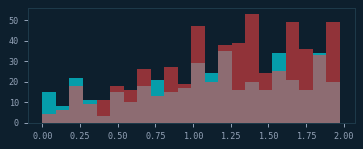
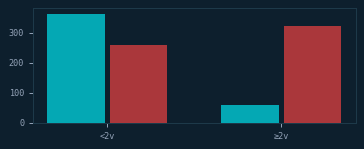

Feature,Tipo
age,⬤ Orig
gender,⬤ Orig
restingbp,⬤ Orig
serumcholestrol,⬤ Orig
fastingbloodsugar,⬤ Orig
restingrelectro,⬤ Orig
maxheartrate,⬤ Orig
exerciseangia,⬤ Orig
oldpeak,⬤ Orig
slope,⬤ Orig


X_train_sm,812 × 18
y_train_sm,812 etiquetas balanceadas
X_val_sc,150 × 18
X_test_sc,150 × 18
scaler,StandardScaler entrenado
FEATURES_FINALES,18 features
fase3.json,→ GitHub Pages · /content/fase3.json


In [22]:
# ║  BLOQUE 1 — HEADER VISUAL FASE 3                                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

header_html = F3_CSS + f"""
<style>
/* ── BOTONES NAVEGACIÓN CON GLOW ─────────────────────────────────────── */
.nav-grid{{
  display:grid;
  grid-template-columns:repeat(3,1fr);
  gap:8px;
  margin-top:24px;
  margin-bottom:0;
}}
.nb{{
  padding:9px 14px;border-radius:10px;font-family:'JetBrains Mono',monospace;
  font-size:.68em;font-weight:700;letter-spacing:.8px;cursor:pointer;
  text-decoration:none;display:flex;align-items:center;gap:8px;
  border:1px solid;transition:all .3s cubic-bezier(.4,0,.2,1);
  position:relative;overflow:hidden;
}}
.nb::before{{
  content:'';position:absolute;inset:0;opacity:0;
  transition:opacity .3s;border-radius:10px;
}}
.nb:hover{{transform:translateY(-2px);}}
.nb:hover::before{{opacity:1;}}

/* Autor — slate */
.nb-autor{{color:#94a3b8;border-color:rgba(148,163,184,.25);background:rgba(148,163,184,.06);}}
.nb-autor::before{{box-shadow:inset 0 0 18px rgba(148,163,184,.15);}}
.nb-autor:hover{{border-color:rgba(148,163,184,.5);box-shadow:0 0 16px rgba(148,163,184,.2);}}

/* Index — cyan */
.nb-idx{{color:var(--cyan);border-color:rgba(0,242,254,.25);background:rgba(0,242,254,.06);}}
.nb-idx::before{{box-shadow:inset 0 0 18px rgba(0,242,254,.12);}}
.nb-idx:hover{{border-color:rgba(0,242,254,.5);box-shadow:0 0 18px rgba(0,242,254,.25);}}

/* Kaggle — orange */
.nb-kg{{color:var(--orng);border-color:rgba(245,158,11,.25);background:rgba(245,158,11,.06);}}
.nb-kg::before{{box-shadow:inset 0 0 18px rgba(245,158,11,.12);}}
.nb-kg:hover{{border-color:rgba(245,158,11,.5);box-shadow:0 0 18px rgba(245,158,11,.25);}}

/* F1 — slate claro */
.nb-f1{{color:#7c8fa6;border-color:rgba(124,143,166,.25);background:rgba(124,143,166,.06);}}
.nb-f1::before{{box-shadow:inset 0 0 18px rgba(124,143,166,.12);}}
.nb-f1:hover{{border-color:rgba(124,143,166,.5);box-shadow:0 0 16px rgba(124,143,166,.18);}}

/* F2 — violet */
.nb-f2{{color:var(--f2v);border-color:rgba(139,92,246,.25);background:rgba(139,92,246,.06);}}
.nb-f2::before{{box-shadow:inset 0 0 18px rgba(139,92,246,.12);}}
.nb-f2:hover{{border-color:rgba(139,92,246,.5);box-shadow:0 0 18px rgba(139,92,246,.25);}}

/* F4 — green */
.nb-f4{{color:var(--green);border-color:rgba(0,255,136,.25);background:rgba(0,255,136,.06);}}
.nb-f4::before{{box-shadow:inset 0 0 18px rgba(0,255,136,.12);}}
.nb-f4:hover{{border-color:rgba(0,255,136,.5);box-shadow:0 0 18px rgba(0,255,136,.25);}}

.nb-icon{{font-size:1em;flex-shrink:0;}}
.nb-label{{font-weight:800;font-size:1em;letter-spacing:1px;}}
.nb-sub{{font-size:.85em;font-weight:400;opacity:.7;margin-left:2px;}}
</style>

<div class="mc" id="main-f3-v10">

  <!-- TÍTULO PRIMERO -->
  <h1 style="font-family:'JetBrains Mono',monospace;font-weight:800;font-size:2.2em;
             margin:0 0 4px;line-height:1.2;color:var(--f3v)">
    Fase 3: Data Preparation</h1>
  <p style="color:#4a5568;font-size:.92em;margin-bottom:0;font-weight:500;letter-spacing:.3px;">
    CRISP-DM · IBM Data Science · Feature Engineering · Encoding · Split · Scaling · SMOTE</p>

  <!-- BOTONES EN GRID 3 columnas -->
  <div class="nav-grid">
    <a href="{URL_AUTOR}"  target="_blank" class="nb nb-autor">
      <span class="nb-icon">◎</span>
      <span><span class="nb-label">AUTOR</span><span class="nb-sub"> / juanjararPYBM</span></span>
    </a>
    <a href="{URL_INDEX}"  target="_blank" class="nb nb-idx">
      <span class="nb-icon">◈</span>
      <span><span class="nb-label">INDEX</span><span class="nb-sub"> / Master Portfolio ↗</span></span>
    </a>
    <a href="{URL_KAGGLE}" target="_blank" class="nb nb-kg">
      <span class="nb-icon">⬡</span>
      <span><span class="nb-label">KAGGLE</span><span class="nb-sub"> / Dataset ↗</span></span>
    </a>
    <a href="{URL_F1}"     target="_blank" class="nb nb-f1">
      <span class="nb-icon">←</span>
      <span><span class="nb-label">FASE 1</span><span class="nb-sub"> / Business Understanding</span></span>
    </a>
    <a href="{URL_F2}"     target="_blank" class="nb nb-f2">
      <span class="nb-icon">←</span>
      <span><span class="nb-label">FASE 2</span><span class="nb-sub"> / Data Understanding</span></span>
    </a>
    <a href="{URL_F4}"     target="_blank" class="nb nb-f4">
      <span class="nb-icon">→</span>
      <span><span class="nb-label">FASE 4</span><span class="nb-sub"> / Modeling</span></span>
    </a>
  </div>

  <div style="height:28px;"></div>

  <!-- PIPELINE UNIFICADO ─────────────────────────────── -->
  <div class="div" style="margin-top:4px;">📋 BLOQUES · PIPELINE DE EJECUCIÓN</div>

  <div class="pu-grid">

    <div class="pu-item pu-b1">
      <div class="pu-step" style="color:var(--f3v);">B1 · presentación</div>
      <div class="pu-title">Header Visual</div>
      <div class="pu-desc">Título, navegación y pipeline de ejecución. Este bloque.</div>
      <div class="pu-tag" style="background:rgba(245,158,11,.12);color:var(--f3v);">◎ estás aquí</div>
    </div>

    <div class="pu-item pu-b2">
      <div class="pu-step" style="color:var(--cyan);">B2 · paso 1</div>
      <div class="pu-title">Setup + Feature Eng.</div>
      <div class="pu-desc">Carga de datos + 3 variables clínicas nuevas desde F2.</div>
      <div class="pu-tag" style="background:rgba(0,242,254,.1);color:var(--cyan);">carga + vars nuevas</div>
    </div>

    <div class="pu-item pu-b3">
      <div class="pu-step" style="color:var(--f2v);">B3 · paso 2</div>
      <div class="pu-title">Encoding</div>
      <div class="pu-desc">One-Hot Encoding. Categorías → números. 16 features finales.</div>
      <div class="pu-tag" style="background:rgba(139,92,246,.1);color:var(--f2v);">cat → num</div>
    </div>

    <div class="pu-item pu-b4">
      <div class="pu-step" style="color:var(--red);">B4 · paso 3</div>
      <div class="pu-title">Train / Val / Test</div>
      <div class="pu-desc">70 · 15 · 15%. Dividir antes de escalar. Stratify activo.</div>
      <div class="pu-tag" style="background:rgba(255,68,68,.1);color:var(--red);">⚠ antes del scaler</div>
    </div>

    <div class="pu-item pu-b5">
      <div class="pu-step" style="color:var(--green);">B5 · paso 4</div>
      <div class="pu-title">Scaling + SMOTE</div>
      <div class="pu-desc">StandardScaler μ=0 σ=1. SMOTE solo sobre train.</div>
      <div class="pu-tag" style="background:rgba(0,255,136,.1);color:var(--green);">solo en train</div>
    </div>

    <div class="pu-item pu-b6">
      <div class="pu-step" style="color:#f59e0b;">B6 · cierre</div>
      <div class="pu-title">Resumen Pipeline</div>
      <div class="pu-desc">Métricas finales. Flujo verificado. Datos listos para F4.</div>
      <div class="pu-tag" style="background:rgba(245,158,11,.1);color:#f59e0b;">✓ verificación</div>
    </div>

    <div class="pu-item pu-b7">
      <div class="pu-step" style="color:var(--green);">B7 · salida</div>
      <div class="pu-title">Exportar → F4</div>
      <div class="pu-desc">Artefactos con %store: arrays, scaler, feature list.</div>
      <div class="pu-tag" style="background:rgba(0,255,136,.1);color:var(--green);">→ Fase 4</div>
    </div>

    <div class="pu-item pu-b8">
      <div class="pu-step" style="color:var(--muted);">B8 · fin</div>
      <div class="pu-title">Conclusiones</div>
      <div class="pu-desc">Implicaciones para F4. Logros de la fase.</div>
      <div class="pu-tag" style="background:rgba(100,116,139,.1);color:var(--muted);">↓ auto</div>
    </div>

  </div>

  <div class="pu-flow">B1 ──▶ B2 ──▶ B3 ──▶ B4 ──▶ B5 ──▶ B6 ──▶ B7 ──▶▶ FASE 4</div>

</div>
<script src="https://cdnjs.cloudflare.com/ajax/libs/gsap/3.12.2/gsap.min.js"></script>
<script>gsap.from("#main-f3-v10",{{duration:1.2,y:30,opacity:0,ease:"power3.out"}});</script>
"""

display(HTML(header_html))



# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOQUE 2 — SETUP · CARGA · FEATURE ENGINEERING                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re, json, warnings
from scipy import stats
from IPython.display import HTML, display
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'figure.facecolor': '#0a141e', 'axes.facecolor': '#0d1f2d',
    'axes.edgecolor': '#1e3a4a',   'text.color': '#c8d6e5',
    'xtick.color': '#c8d6e5',      'ytick.color': '#c8d6e5',
    'grid.color': '#1e3a4a',       'axes.grid': True,
    'font.family': 'monospace',
})

# ─── RUTAS ────────────────────────────────────────────────────────────────────
URL_AUTOR  = "https://github.com/juanjararPYBM/ibm-data-science-portfolio"
URL_INDEX  = "https://colab.research.google.com/github/juanjararPYBM/ibm-data-science-portfolio/blob/main/proyecto_medico/Master_Index.ipynb"
URL_KAGGLE = "https://www.kaggle.com/datasets/jocelyndumlao/cardiovascular-disease-dataset"
URL_F1     = "https://colab.research.google.com/github/juanjararPYBM/ibm-data-science-portfolio/blob/main/proyecto_medico/Fase1_Business_Understanding.ipynb"
URL_F2     = "https://colab.research.google.com/github/juanjararPYBM/ibm-data-science-portfolio/blob/main/proyecto_medico/Fase2_Data_Understanding.ipynb"
URL_F4     = "https://colab.research.google.com/github/juanjararPYBM/ibm-data-science-portfolio/blob/main/proyecto_medico/Fase4_Modeling.ipynb"
KAGGLE_DATASET = "jocelyndumlao/cardiovascular-disease-dataset"

# ─── CSS MAESTRO (identidad visual F1/F2) ─────────────────────────────────────
F3_CSS = """
<style>
@import url('https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@400;600;700;800&family=Inter:wght@300;400;600&display=swap');
:root{--f3v:#f59e0b;--arctic:#f8fafc;--cyan:#00f2fe;--red:#ff4444;
      --green:#00ff88;--bg:#0a141e;--surf:#0d1f2d;--f2v:#8b5cf6;
      --pink:#ff69b4;--bdr:rgba(255,255,255,.07);--txt:#c8d6e5;--muted:#4a5568;}
*,*::before,*::after{box-sizing:border-box}
.mc{background:var(--bg);border-radius:20px;padding:40px 44px;max-width:980px;
    margin:0 auto;box-shadow:0 0 0 1px var(--bdr),0 24px 80px rgba(0,0,0,.7);
    font-family:'Inter',sans-serif;}
.rev-btns{display:flex;gap:10px;flex-wrap:wrap;margin-bottom:28px}
.rb{padding:8px 18px;border-radius:8px;font-family:'JetBrains Mono',monospace;
    font-size:.72em;font-weight:700;letter-spacing:1px;cursor:pointer;
    text-decoration:none;display:inline-flex;align-items:center;gap:7px;
    border:1px solid;transition:all .25s;}
.rb:hover{transform:translateY(-2px);box-shadow:0 6px 20px rgba(0,0,0,.4)}
.bf2{color:#94a3b8;border-color:rgba(148,163,184,.3);background:rgba(148,163,184,.07)}
.bidx{color:var(--cyan);border-color:rgba(0,242,254,.3);background:rgba(0,242,254,.07)}
.bkg{color:var(--f3v);border-color:rgba(245,158,11,.3);background:rgba(245,158,11,.07)}
.bf4{color:var(--green);border-color:rgba(0,255,136,.3);background:rgba(0,255,136,.07)}
.ig{display:grid;grid-template-columns:repeat(4,1fr);gap:8px;margin-bottom:30px}
.ic{background:var(--surf);border:1px solid var(--bdr);border-radius:10px;
    padding:12px 14px;transition:all .22s;cursor:default}
.ic:hover{border-color:rgba(255,255,255,.15);transform:translateY(-2px)}
.ic.active{border-color:rgba(245,158,11,.4);background:rgba(245,158,11,.08)}
.ic-n{font-family:'JetBrains Mono',monospace;font-size:.58em;color:var(--muted);
      letter-spacing:2px;text-transform:uppercase;margin-bottom:5px}
.ic-l{color:var(--arctic);font-size:.78em;font-weight:600;line-height:1.3}
.div{font-family:'JetBrains Mono',monospace;font-size:.62em;font-weight:700;
     letter-spacing:3px;text-transform:uppercase;color:var(--muted);
     padding:10px 0 14px;border-bottom:1px solid var(--bdr);margin-bottom:20px;}
.step-card{background:var(--surf);border:1px solid var(--bdr);border-radius:14px;
           padding:20px 24px;margin-bottom:14px;border-left:4px solid var(--f3v);}
.step-num{font-family:'JetBrains Mono',monospace;font-size:.6em;color:var(--f3v);
          letter-spacing:3px;text-transform:uppercase;margin-bottom:6px;}
.step-title{font-family:'JetBrains Mono',monospace;font-size:.92em;font-weight:700;
            color:var(--arctic);margin-bottom:8px;}
.step-body{font-size:.83em;color:var(--txt);line-height:1.7;}
.insight{background:rgba(245,158,11,.06);border:1px solid rgba(245,158,11,.2);
         border-left:4px solid var(--f3v);border-radius:0 12px 12px 0;
         padding:14px 18px;margin:12px 0;font-size:.83em;line-height:1.7;}
.insight-green{background:rgba(0,255,136,.05);border:1px solid rgba(0,255,136,.2);
               border-left:4px solid var(--green);border-radius:0 12px 12px 0;
               padding:14px 18px;margin:12px 0;font-size:.83em;line-height:1.7;}
.insight-cyan{background:rgba(0,242,254,.05);border:1px solid rgba(0,242,254,.2);
              border-left:4px solid var(--cyan);border-radius:0 12px 12px 0;
              padding:14px 18px;margin:12px 0;font-size:.83em;line-height:1.7;}
.insight-red{background:rgba(255,68,68,.05);border:1px solid rgba(255,68,68,.2);
             border-left:4px solid var(--red);border-radius:0 12px 12px 0;
             padding:14px 18px;margin:12px 0;font-size:.83em;line-height:1.7;}
.tag{display:inline-block;padding:3px 10px;border-radius:99px;font-family:'JetBrains Mono',monospace;
     font-size:.65em;font-weight:700;letter-spacing:1px;margin:2px;}
.tag-ok{background:rgba(0,255,136,.12);color:var(--green);border:1px solid rgba(0,255,136,.3)}
.tag-warn{background:rgba(245,158,11,.12);color:var(--f3v);border:1px solid rgba(245,158,11,.3)}
.tag-info{background:rgba(0,242,254,.1);color:var(--cyan);border:1px solid rgba(0,242,254,.3)}
.tag-red{background:rgba(255,68,68,.1);color:var(--red);border:1px solid rgba(255,68,68,.3)}
.metric-grid{display:grid;grid-template-columns:repeat(4,1fr);gap:14px;margin:20px 0;}
.metric-card{background:var(--surf);border:1px solid var(--bdr);border-radius:14px;
             padding:18px 16px;text-align:center;}
.metric-val{font-family:'JetBrains Mono',monospace;font-size:1.8em;font-weight:800;line-height:1;}
.metric-lbl{font-family:'JetBrains Mono',monospace;font-size:.58em;color:var(--muted);
            letter-spacing:2px;text-transform:uppercase;margin-top:6px;}

.blk-banner{border-radius:12px;padding:16px 22px;margin-bottom:22px;
            display:flex;align-items:center;gap:16px;
            border-left:4px solid;}
.blk-num{font-family:'JetBrains Mono',monospace;font-size:.58em;font-weight:800;
         letter-spacing:3px;text-transform:uppercase;opacity:.8;}
.blk-title{font-family:'JetBrains Mono',monospace;font-size:1.05em;font-weight:800;
           color:var(--arctic);line-height:1.2;}
.blk-sub{font-size:.78em;color:var(--txt);margin-top:3px;line-height:1.5;}
.blk-b3{background:rgba(0,242,254,.06);border-color:var(--cyan);}
.blk-b4{background:rgba(139,92,246,.06);border-color:var(--f2v);}
.blk-b5{background:rgba(255,68,68,.06);border-color:var(--red);}
.blk-b6{background:rgba(0,255,136,.06);border-color:var(--green);}
.blk-b7{background:rgba(255,179,0,.06);border-color:#ffb300;}
.status-ok{display:inline-flex;align-items:center;gap:8px;
           background:rgba(0,255,136,.08);border:1px solid rgba(0,255,136,.25);
           border-radius:8px;padding:8px 16px;font-family:'JetBrains Mono',monospace;
           font-size:.72em;color:var(--green);font-weight:700;margin-top:14px;}
.status-dot{width:8px;height:8px;border-radius:50%;background:var(--green);
            box-shadow:0 0 8px var(--green);animation:pulse 2s infinite;}
@keyframes pulse{0%,100%{opacity:1;}50%{opacity:.4;}}


.pu-grid{display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin-bottom:18px;}
.pu-item{background:var(--surf);border:1px solid var(--bdr);border-radius:12px;
  padding:14px 14px 28px;position:relative;transition:all .28s cubic-bezier(.4,0,.2,1);
  cursor:default;overflow:hidden;}
.pu-item::after{content:'';position:absolute;bottom:0;left:0;right:0;
  height:3px;opacity:.55;transition:opacity .28s,height .28s;}
.pu-item:hover{transform:translateY(-3px);}
.pu-item:hover::after{opacity:1;height:4px;}
.pu-b1{border-color:rgba(245,158,11,.3);background:rgba(245,158,11,.06);}
.pu-b1::after{background:var(--f3v);}
.pu-b1:hover{border-color:rgba(245,158,11,.55);box-shadow:0 0 22px rgba(245,158,11,.13);}
.pu-b2::after{background:#475569;}
.pu-b2:hover{border-color:rgba(71,85,105,.45);box-shadow:0 0 18px rgba(71,85,105,.1);}
.pu-b3::after{background:var(--cyan);}
.pu-b3:hover{border-color:rgba(0,242,254,.45);box-shadow:0 0 22px rgba(0,242,254,.12);}
.pu-b4::after{background:var(--f2v);}
.pu-b4:hover{border-color:rgba(139,92,246,.45);box-shadow:0 0 22px rgba(139,92,246,.12);}
.pu-b5::after{background:var(--red);}
.pu-b5:hover{border-color:rgba(255,68,68,.45);box-shadow:0 0 22px rgba(255,68,68,.1);}
.pu-b6::after{background:var(--green);}
.pu-b6:hover{border-color:rgba(0,255,136,.45);box-shadow:0 0 22px rgba(0,255,136,.1);}
.pu-b7::after{background:#f59e0b;}
.pu-b7:hover{border-color:rgba(245,158,11,.45);box-shadow:0 0 22px rgba(245,158,11,.1);}
.pu-b8::after{background:var(--green);}
.pu-b8:hover{border-color:rgba(0,255,136,.45);box-shadow:0 0 22px rgba(0,255,136,.1);}
.pu-step{font-family:'JetBrains Mono',monospace;font-size:.52em;
  letter-spacing:2.5px;text-transform:uppercase;margin-bottom:6px;}
.pu-title{font-family:'JetBrains Mono',monospace;font-size:.84em;
  font-weight:700;color:var(--arctic);margin-bottom:6px;line-height:1.3;}
.pu-desc{font-size:.7em;color:var(--muted);line-height:1.55;}
.pu-tag{display:inline-block;margin-top:9px;font-family:'JetBrains Mono',monospace;
  font-size:.58em;padding:2px 8px;border-radius:5px;font-weight:700;}
.pu-flow{font-family:'JetBrains Mono',monospace;font-size:.6em;letter-spacing:3px;
  color:#1e3a4a;text-align:center;padding-bottom:6px;}
</style>
"""

# ─── CARGA ROBUSTA (heredada de F2) ──────────────────────────────────────────
def cargar_datos():
    # INTENTO 1: Recuperar df persistido desde F2 con %store
    # Esto funciona si ya corriste F2 en esta sesión de Colab
    try:
        import io as _io, contextlib as _cl
        _buf = _io.StringIO()
        with _cl.redirect_stdout(_buf), _cl.redirect_stderr(_buf):
            get_ipython().run_line_magic('store', '-r df')
        _df = get_ipython().user_ns.get('df')
        if isinstance(_df, pd.DataFrame) and len(_df) > 0:
            return _df
    except: pass

    # INTENTO 2: Descargar desde Kaggle via kagglehub
    try:
        import kagglehub, os, glob
        import io, contextlib
        _buf = io.StringIO()
        with contextlib.redirect_stdout(_buf), contextlib.redirect_stderr(_buf):
            path = kagglehub.dataset_download(KAGGLE_DATASET)
        csvs = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
        _df  = pd.read_csv(csvs[0])
        _df.columns = [c.strip().replace(' ','_') for c in _df.columns]
        get_ipython().user_ns['df'] = _df
        return _df
    except Exception as e:
        pass

    raise RuntimeError("❌ No se pudo cargar df. Corre F2 primero o sube el CSV manualmente.")

def resolver_columnas(df):
    # Normaliza nombres de columnas para que siempre sean consistentes
    canon = {
        'patientid':'patientid','age':'age','gender':'gender',
        'chestpain':'chestpain','restingbp':'restingBP',
        'serumcholestrol':'serumcholestrol','fastingbloodsugar':'fastingbloodsugar',
        'restingrelectro':'restingrelectro','maxheartrate':'maxheartrate',
        'exerciseangia':'exerciseangia','oldpeak':'oldpeak',
        'slope':'slope','noofmajorvessels':'noofmajorvessels','target':'target'
    }
    rn = {c: canon[c.lower()] for c in df.columns if c.lower() in canon and canon[c.lower()] != c}
    if rn:
        df = df.rename(columns=rn)
        # print(f"   ↳ Renombradas: {rn}")
    return df

# Cargar
df = cargar_datos()
df = resolver_columnas(df)





# ── CALCULAR FEATURES (sin output) ────────────────────────────────────────────
df_feat = df.copy()
df_feat['slope_x_oldpeak'] = df_feat['slope'] * df_feat['oldpeak']
df_feat['log_oldpeak']     = np.log1p(df_feat['oldpeak'])
df_feat['vessels_bin']     = (df_feat['noofmajorvessels'] >= 2).astype(int)


# ── PRE-COMPUTAR HISTOGRAMAS → JSON pequeño ───────────────────────────────────
import numpy as _np, json as _json

def _hist(arr, bins=22):
    c, e = _np.histogram(arr, bins=bins)
    return {'x': ((e[:-1]+e[1:])/2).round(4).tolist(),
            'y': c.tolist(), 'w': float(round(e[1]-e[0], 5))}

_f1 = df_feat['slope_x_oldpeak']
_f2 = df_feat['log_oldpeak']
_s  = df_feat['target'] == 0
_r  = df_feat['target'] == 1

_DJ = _json.dumps({
    'n':      len(df),
    'riesgo': int(df['target'].sum()),
    'sano':   int((_s).sum()),
    'f1': {
        'sano':   _hist(_f1[_s]), 'riesgo': _hist(_f1[_r]),
        'med_s':  round(float(_f1[_s].median()), 2),
        'med_r':  round(float(_f1[_r].median()), 2),
        'rng':    [round(float(_f1.min()), 1), round(float(_f1.max()), 1)],
    },
    'f2': {
        'sano':   _hist(_f2[_s]), 'riesgo': _hist(_f2[_r]),
        'med_s':  round(float(_f2[_s].median()), 3),
        'med_r':  round(float(_f2[_r].median()), 3),
        'rng':    [round(float(_f2.min()), 3), round(float(_f2.max()), 3)],
        'thr':    round(float(_np.log1p(1.5)), 3),
    },
    'f3': {
        'lt2_s': int(df_feat[_s & (df_feat['vessels_bin']==0)].shape[0]),
        'lt2_r': int(df_feat[_r & (df_feat['vessels_bin']==0)].shape[0]),
        'ge2_s': int(df_feat[_s & (df_feat['vessels_bin']==1)].shape[0]),
        'ge2_r': int(df_feat[_r & (df_feat['vessels_bin']==1)].shape[0]),
    }
})

# ── HTML (string normal, sin f-string) ────────────────────────────────────────


# ── HTML + Canvas puro (sin librerías externas) ───────────────────────────────


# ── GENERAR CHARTS COMO SVG INLINE (Python → SVG string) ──────────────────────
import io as _io, base64 as _b64
import matplotlib.pyplot as _plt
import matplotlib.patches as _mp
import numpy as _np

_plt.rcParams.update({
    'figure.facecolor':'#0d1f2d','axes.facecolor':'#0d1f2d',
    'axes.edgecolor':'#1e3a4a','text.color':'#c8d6e5',
    'xtick.color':'#94a3b8','ytick.color':'#94a3b8',
    'axes.grid':False,'font.family':'monospace','xtick.labelsize':7,'ytick.labelsize':7,
})

_s = df_feat['target']==0
_r = df_feat['target']==1

def _svg(fig):
    buf = _io.StringIO()
    fig.savefig(buf, format='svg', bbox_inches='tight', facecolor=fig.get_facecolor())
    svg = buf.getvalue()
    # strip XML declaration and doctype, keep only <svg...>...</svg>
    start = svg.find('<svg')
    return svg[start:]

def _png64(fig):
    buf = _io.BytesIO()
    fig.savefig(buf, format='png', dpi=88, bbox_inches='tight', facecolor=fig.get_facecolor())
    buf.seek(0)
    return _b64.b64encode(buf.read()).decode()

# ── Mini thumbnails (PNG base64) ──────────────────────────────────────────────
def _mini_hist(col):
    fig, ax = _plt.subplots(figsize=(4,1.55))
    ax.hist(df_feat[_s][col], bins=22, color='#00f2fe', alpha=.6, edgecolor='none')
    ax.hist(df_feat[_r][col], bins=22, color='#ff4444', alpha=.55, edgecolor='none')
    for sp in ax.spines.values(): sp.set_color('#1e3a4a')
    _plt.tight_layout(pad=.2)
    b = _png64(fig); _plt.close(fig); return b

def _mini_bar():
    fig, ax = _plt.subplots(figsize=(4,1.55))
    vb = df_feat.groupby(['vessels_bin','target']).size().unstack(fill_value=0)
    x  = _np.array([0,1])
    ax.bar(x-.18, vb[0], .33, color='#00f2fe', alpha=.65)
    ax.bar(x+.18, vb[1], .33, color='#ff4444', alpha=.65)
    ax.set_xticks(x); ax.set_xticklabels(['<2v','≥2v'])
    for sp in ax.spines.values(): sp.set_color('#1e3a4a')
    _plt.tight_layout(pad=.2)
    b = _png64(fig); _plt.close(fig); return b

_IMG1 = _mini_hist('slope_x_oldpeak')
_IMG2 = _mini_hist('log_oldpeak')
_IMG3 = _mini_bar()

# ── Full charts (SVG inline para panel expandido) ─────────────────────────────
def _full_hist(col, med_s, med_r, extra_lines=None):
    fig, ax = _plt.subplots(figsize=(6, 3.2))
    ax.hist(df_feat[_s][col], bins=22, color='#00f2fe', alpha=.6,
            edgecolor='none', label='Sano')
    ax.hist(df_feat[_r][col], bins=22, color='#ff4444', alpha=.55,
            edgecolor='none', label='Riesgo CV')
    ax.axvline(med_s, color='#00f2fe', lw=1.4, ls='--', alpha=.75,
               label=f'med.sano={med_s}')
    ax.axvline(med_r, color='#ff4444', lw=1.4, ls='--', alpha=.75,
               label=f'med.riesgo={med_r}')
    if extra_lines:
        for xv, col2, lbl in extra_lines:
            ax.axvline(xv, color=col2, lw=1.8, ls='-.', alpha=.85, label=lbl)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('pacientes', fontsize=8)
    lg = ax.legend(fontsize=7, framealpha=.15, edgecolor='#1e3a4a',
                   labelcolor='#c8d6e5')
    lg.get_frame().set_facecolor('#0d1f2d')
    for sp in ax.spines.values(): sp.set_color('#1e3a4a')
    ax.tick_params(colors='#94a3b8')
    _plt.tight_layout(pad=.4)
    s = _svg(fig); _plt.close(fig); return s

def _full_bar():
    fig, ax = _plt.subplots(figsize=(5, 3.2))
    vb = df_feat.groupby(['vessels_bin','target']).size().unstack(fill_value=0)
    x  = _np.array([0,1])
    b1 = ax.bar(x-.2, vb[0], .38, color='#00f2fe', alpha=.65, label='Sano')
    b2 = ax.bar(x+.2, vb[1], .38, color='#ff4444', alpha=.65, label='Riesgo CV')
    ax.set_xticks(x)
    ax.set_xticklabels(['< 2 vasos','≥ 2 vasos'], fontsize=9)
    for bar, val in zip(list(b1)+list(b2),
                        list(vb[0])+list(vb[1])):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+4,
                str(int(val)), ha='center', fontsize=8, color='#c8d6e5')
    ax.set_ylabel('pacientes', fontsize=8)
    lg = ax.legend(fontsize=7, framealpha=.15, edgecolor='#1e3a4a',
                   labelcolor='#c8d6e5')
    lg.get_frame().set_facecolor('#0d1f2d')
    for sp in ax.spines.values(): sp.set_color('#1e3a4a')
    ax.tick_params(colors='#94a3b8')
    _plt.tight_layout(pad=.4)
    s = _svg(fig); _plt.close(fig); return s

_f1c = df_feat['slope_x_oldpeak']
_f2c = df_feat['log_oldpeak']
_thr = float(_np.log1p(1.5))

_SVG1 = _full_hist('slope_x_oldpeak',
    round(float(_f1c[_s].median()),2), round(float(_f1c[_r].median()),2))
_SVG2 = _full_hist('log_oldpeak',
    round(float(_f2c[_s].median()),3), round(float(_f2c[_r].median()),3),
    extra_lines=[(_thr, '#f59e0b', f'umbral clínico={round(_thr,3)}')])
_SVG3 = _full_bar()

# ── Métricas para zonas ───────────────────────────────────────────────────────
_lt2_s = int(df_feat[_s&(df_feat['vessels_bin']==0)].shape[0])
_lt2_r = int(df_feat[_r&(df_feat['vessels_bin']==0)].shape[0])
_ge2_s = int(df_feat[_s&(df_feat['vessels_bin']==1)].shape[0])
_ge2_r = int(df_feat[_r&(df_feat['vessels_bin']==1)].shape[0])
_pct_lt = round(_lt2_s/(_lt2_s+_lt2_r)*100)
_pct_ge = round(_ge2_r/(_ge2_s+_ge2_r)*100)

_status = (
    f'kagglehub &nbsp;·&nbsp; <b>{len(df):,}</b> registros &nbsp;·&nbsp; '
    f'riesgo <span style="color:#f59e0b;font-weight:700;">{int(df["target"].sum())}</span>'
    f' &nbsp;·&nbsp; sano <span style="color:#00f2fe;font-weight:700;">{int((_s).sum())}</span>'
)

# ── HTML final ────────────────────────────────────────────────────────────────
_HTML = F3_CSS + f"""
<style>
.b2w{{border:1px solid rgba(0,242,254,.18);border-radius:18px;overflow:hidden;
     background:linear-gradient(160deg,rgba(0,242,254,.025),rgba(0,242,254,.005));}}
.b2-status{{display:flex;align-items:center;gap:10px;padding:9px 22px;
           border-bottom:1px solid rgba(255,255,255,.05);}}
.b2-dot{{width:7px;height:7px;border-radius:50%;background:#00ff88;
        box-shadow:0 0 7px #00ff88;animation:pulse 2s infinite;flex-shrink:0;}}
.b2sl{{font-family:'JetBrains Mono',monospace;font-size:.65em;font-weight:700;color:#00ff88;}}
.b2sd{{font-family:'JetBrains Mono',monospace;font-size:.63em;color:#4a5568;}}
.b2-hdr{{padding:18px 26px 12px;display:flex;align-items:flex-start;gap:14px;}}
.b2-blk{{font-family:'JetBrains Mono',monospace;font-size:.57em;color:var(--cyan);
        letter-spacing:3px;text-transform:uppercase;margin-bottom:4px;}}
.b2-title{{font-family:'JetBrains Mono',monospace;font-size:1.02em;font-weight:800;
          color:var(--arctic);margin-bottom:5px;}}
.b2-sub{{font-size:.78em;color:var(--txt);line-height:1.6;}}

/* details/summary reset */
details{{list-style:none;margin:0 22px 16px;}}
details:last-of-type{{margin-bottom:22px;}}
details summary{{list-style:none;cursor:pointer;outline:none;}}
details summary::-webkit-details-marker{{display:none;}}

/* mini card (summary) */
.fm{{border-radius:14px;border:1px solid var(--bdr);background:var(--surf);
     overflow:hidden;transition:border-color .25s,box-shadow .25s;
     display:grid;grid-template-columns:200px 1fr;align-items:center;}}
.fm:hover{{box-shadow:0 8px 32px rgba(0,0,0,.5);}}
.fm-c1{{border-left:3px solid rgba(0,242,254,.5);}}
.fm-c1:hover,.fm-c1.open{{border-color:rgba(0,242,254,.6);
    box-shadow:0 8px 32px rgba(0,0,0,.5),0 0 20px rgba(0,242,254,.08);}}
.fm-c2{{border-left:3px solid rgba(0,255,136,.5);}}
.fm-c2:hover,.fm-c2.open{{border-color:rgba(0,255,136,.6);
    box-shadow:0 8px 32px rgba(0,0,0,.5),0 0 20px rgba(0,255,136,.08);}}
.fm-c3{{border-left:3px solid rgba(245,158,11,.5);}}
.fm-c3:hover,.fm-c3.open{{border-color:rgba(245,158,11,.6);
    box-shadow:0 8px 32px rgba(0,0,0,.5),0 0 20px rgba(245,158,11,.08);}}
.fm-thumb{{width:200px;height:90px;object-fit:cover;display:block;border-radius:0;}}
.fm-meta{{padding:12px 18px;}}
.fm-lbl{{font-family:'JetBrains Mono',monospace;font-size:.56em;font-weight:800;
        letter-spacing:2.5px;text-transform:uppercase;margin-bottom:5px;}}
.fm-formula{{font-family:'JetBrains Mono',monospace;font-size:.76em;
            background:rgba(255,255,255,.06);border-radius:6px;
            padding:4px 10px;color:var(--arctic);display:inline-block;margin-bottom:4px;}}
.fm-hint{{font-size:.62em;color:var(--muted);}}

/* expanded panel */
.fe-panel{{border-radius:0 0 14px 14px;border:1px solid rgba(255,255,255,.08);
          border-top:none;background:rgba(10,20,30,.9);
          display:grid;grid-template-columns:55% 45%;overflow:hidden;
          margin-top:-2px;}}
.fe-chart{{padding:16px;border-right:1px solid rgba(255,255,255,.05);}}
.fe-chart svg{{width:100%;height:auto;display:block;border-radius:6px;}}
.fe-info{{padding:18px 16px;display:flex;flex-direction:column;gap:10px;
         overflow-y:auto;max-height:400px;}}
.fi-lbl{{font-family:'JetBrains Mono',monospace;font-size:.56em;font-weight:800;
        letter-spacing:3px;text-transform:uppercase;}}
.fi-code{{font-family:'JetBrains Mono',monospace;font-size:.8em;
         background:rgba(255,255,255,.05);border-radius:8px;padding:7px 13px;
         color:var(--arctic);border-left:3px solid;display:block;margin:6px 0;}}
.fi-desc{{font-size:.76em;color:var(--txt);line-height:1.65;}}
.fi-rng{{font-family:'JetBrains Mono',monospace;font-size:.62em;color:var(--arctic);
        opacity:.65;padding:6px 10px;background:rgba(255,255,255,.03);border-radius:7px;}}
.fi-zt{{font-family:'JetBrains Mono',monospace;font-size:.53em;letter-spacing:2px;
       text-transform:uppercase;color:var(--muted);margin-bottom:4px;}}
.fi-zone{{border-radius:10px;border:1px solid rgba(255,255,255,.07);
         background:rgba(0,0,0,.2);padding:9px 13px;transition:all .2s;}}
.fi-zone:hover{{border-color:rgba(var(--zc),.45)!important;
               background:rgba(var(--zc),.07)!important;
               box-shadow:0 0 16px rgba(var(--zc),.12)!important;}}
.fi-zone-lbl{{font-family:'JetBrains Mono',monospace;font-size:.57em;
             font-weight:700;letter-spacing:1.5px;text-transform:uppercase;margin-bottom:4px;}}
.fi-zone-txt{{font-size:.73em;color:var(--txt);line-height:1.6;}}

/* grid mini para 3 features lado a lado */
.fe-grid3{{display:grid;grid-template-columns:repeat(3,1fr);gap:10px;
           padding:0 22px 6px;}}
.fe-grid3 details{{margin:0;}}
.fe-grid3 .fm{{display:block;}}
.fe-grid3 .fm-thumb{{width:100%;height:100px;}}
.fe-grid3 .fm-meta{{padding:9px 12px 12px;}}
.fe-grid3 .fe-panel{{grid-template-columns:1fr;}}
</style>

<div class="mc" style="padding:0;">
<div class="b2w">

  <div class="b2-status">
    <div class="b2-dot"></div>
    <span class="b2sl">DATOS CARGADOS</span>
    <span class="b2sd">{_status}</span>
  </div>

  <div class="b2-hdr">
    <div style="font-size:2em;line-height:1;filter:drop-shadow(0 0 10px rgba(0,242,254,.4))">&#128300;</div>
    <div>
      <div class="b2-blk">Bloque 2 &middot; Setup &middot; Carga &middot; Feature Engineering</div>
      <div class="b2-title">Crear variables con significado cl&iacute;nico</div>
      <div class="b2-sub">Del mismo modo que en medicina calculamos el <strong>&iacute;ndice de shock</strong>
        (FC&divide;PAS) &mdash; aqu&iacute; creamos 3 variables que capturan lo que ninguna original describe sola.
        <em style="color:var(--muted);">Click en un card para expandir.</em>
      </div>
    </div>
  </div>

  <!-- ── F1 ── -->
  <details>
    <summary>
      <div class="fm fm-c1">
        <img class="fm-thumb" src="data:image/png;base64,{_IMG1}" alt="">
        <div class="fm-meta">
          <div class="fm-lbl" style="color:var(--cyan);">F1 &middot; Interacci&oacute;n</div>
          <div class="fm-formula">slope &times; oldpeak</div>
          <div class="fm-hint">&#8853; click para expandir</div>
        </div>
      </div>
    </summary>
    <div class="fe-panel" style="border-color:rgba(0,242,254,.2);">
      <div class="fe-chart">{_SVG1}</div>
      <div class="fe-info">
        <div><div class="fi-lbl" style="color:var(--cyan);">F1 &middot; Interacci&oacute;n</div>
        <code class="fi-code" style="border-left-color:var(--cyan);">slope &times; oldpeak</code></div>
        <div class="fi-desc">F2 confirm&oacute; que <em>slope</em> y <em>oldpeak</em> forman el
          <strong>Trio El&eacute;ctrico</strong>. Su producto captura la interacci&oacute;n: pendiente
          descendente del ST + depresi&oacute;n ST simult&aacute;nea = se&ntilde;al m&aacute;xima de
          riesgo isqu&eacute;mico.</div>
        <div class="fi-rng">
          Rango: {round(float(_f1c.min()),1)} &ndash; {round(float(_f1c.max()),1)} &nbsp;|&nbsp;
          med. sano: <span style="color:#00f2fe;">{round(float(_f1c[_s].median()),2)}</span> &nbsp;
          med. riesgo: <span style="color:#ff4444;">{round(float(_f1c[_r].median()),2)}</span>
        </div>
        <div class="fi-zt">&#128202; zonas cl&iacute;nicas</div>
        <div class="fi-zone" style="--zc:0,242,254;">
          <div class="fi-zone-lbl" style="color:rgba(0,242,254,.9);">Zona segura (0&ndash;2)</div>
          <div class="fi-zone-txt">Valores 0&ndash;2: <strong style="color:#00f2fe;">Sano</strong> domina.
            Oldpeak bajo + slope normal = coraz&oacute;n que se recupera bien del estr&eacute;s.</div>
        </div>
        <div class="fi-zone" style="--zc:148,163,184;">
          <div class="fi-zone-lbl" style="color:rgba(148,163,184,.9);">Zona mixta (2&ndash;6)</div>
          <div class="fi-zone-txt">Distribuciones se superponen. El modelo combinar&aacute;
            otras variables para desambiguar.</div>
        </div>
        <div class="fi-zone" style="--zc:255,68,68;">
          <div class="fi-zone-lbl" style="color:rgba(255,68,68,.9);">Zona de riesgo (&gt;6)</div>
          <div class="fi-zone-txt"><strong style="color:#ff4444;">Riesgo CV</strong> predomina.
            Oldpeak elevado + slope descendente = isquemia severa durante el ejercicio.</div>
        </div>
      </div>
    </div>
  </details>

  <!-- ── F2 ── -->
  <details>
    <summary>
      <div class="fm fm-c2">
        <img class="fm-thumb" src="data:image/png;base64,{_IMG2}" alt="">
        <div class="fm-meta">
          <div class="fm-lbl" style="color:var(--green);">F2 &middot; Logar&iacute;tmica</div>
          <div class="fm-formula">log(oldpeak + 1)</div>
          <div class="fm-hint">&#8853; click para expandir</div>
        </div>
      </div>
    </summary>
    <div class="fe-panel" style="border-color:rgba(0,255,136,.2);">
      <div class="fe-chart">{_SVG2}</div>
      <div class="fe-info">
        <div><div class="fi-lbl" style="color:var(--green);">F2 &middot; Logar&iacute;tmica</div>
        <code class="fi-code" style="border-left-color:var(--green);">log(oldpeak + 1)</code></div>
        <div class="fi-desc"><em>oldpeak</em> tiene distribuci&oacute;n muy sesgada a la derecha:
          muchos valores en 0, pocos valores altos. <strong>log1p</strong> comprime esa escala
          asim&eacute;tricamente &mdash; igual que con troponina en laboratorio cl&iacute;nico.
          El +1 evita log(0), que es indefinido matem&aacute;ticamente.</div>
        <div class="fi-rng">
          Rango: {round(float(_f2c.min()),3)} &ndash; {round(float(_f2c.max()),3)} &nbsp;|&nbsp;
          umbral cl&iacute;nico: <span style="color:#f59e0b;">{round(_thr,3)}</span>
          (oldpeak = 1.5 mmV)
        </div>
        <div class="fi-zt">&#128202; zonas cl&iacute;nicas</div>
        <div class="fi-zone" style="--zc:0,242,254;">
          <div class="fi-zone-lbl" style="color:rgba(0,242,254,.9);">Sin depresi&oacute;n ST (&lt;0.4)</div>
          <div class="fi-zone-txt">Equivale a oldpeak &lt;0.49 mmV: sin depresi&oacute;n ST
            significativa. <strong style="color:#00f2fe;">Sano</strong> domina claramente.</div>
        </div>
        <div class="fi-zone" style="--zc:245,158,11;">
          <div class="fi-zone-lbl" style="color:rgba(245,158,11,.9);">Depresi&oacute;n leve&ndash;moderada</div>
          <div class="fi-zone-txt">Zona de transici&oacute;n hasta el umbral cl&iacute;nico
            ({round(_thr,3)}). La separaci&oacute;n entre clases empieza a ser visible.</div>
        </div>
        <div class="fi-zone" style="--zc:255,68,68;">
          <div class="fi-zone-lbl" style="color:rgba(255,68,68,.9);">Depresi&oacute;n &ge;1.5 mmV</div>
          <div class="fi-zone-txt"><strong style="color:#ff4444;">Riesgo CV</strong> predomina
            a la derecha del umbral. Esta l&iacute;nea tiene valor diagn&oacute;stico real en cardiolog&iacute;a.</div>
        </div>
      </div>
    </div>
  </details>

  <!-- ── F3 ── -->
  <details>
    <summary>
      <div class="fm fm-c3">
        <img class="fm-thumb" src="data:image/png;base64,{_IMG3}" alt="">
        <div class="fm-meta">
          <div class="fm-lbl" style="color:var(--f3v);">F3 &middot; Umbral Cl&iacute;nico</div>
          <div class="fm-formula">vasos &ge; 2 &rarr; 1</div>
          <div class="fm-hint">&#8853; click para expandir</div>
        </div>
      </div>
    </summary>
    <div class="fe-panel" style="border-color:rgba(245,158,11,.2);">
      <div class="fe-chart">{_SVG3}</div>
      <div class="fe-info">
        <div><div class="fi-lbl" style="color:var(--f3v);">F3 &middot; Umbral Cl&iacute;nico</div>
        <code class="fi-code" style="border-left-color:var(--f3v);">vasos &ge; 2 &rarr; 1</code></div>
        <div class="fi-desc">F2 mostr&oacute; que &ge;2 vasos obstruidos = <strong>enfermedad
          multivaso</strong>, umbral de riesgo cl&iacute;nico real. Binarizamos en ese corte:
          la informaci&oacute;n relevante es el <em>umbral</em>, no el n&uacute;mero exacto de vasos.</div>
        <div class="fi-rng">
          Variable binaria &nbsp;|&nbsp;
          &lt;2 vasos: {_lt2_s+_lt2_r} pac. &nbsp;&middot;&nbsp;
          &ge;2 vasos: {_ge2_s+_ge2_r} pac.
        </div>
        <div class="fi-zt">&#128202; zonas cl&iacute;nicas</div>
        <div class="fi-zone" style="--zc:0,242,254;">
          <div class="fi-zone-lbl" style="color:rgba(0,242,254,.9);">&lt;2 vasos</div>
          <div class="fi-zone-txt">
            <strong style="color:#00f2fe;">{_lt2_s} sano</strong> vs
            <strong style="color:#ff4444;">{_lt2_r} riesgo</strong>.
            Sano = {_pct_lt}% del grupo &mdash; sin enfermedad multivaso predominan los pacientes sanos.</div>
        </div>
        <div class="fi-zone" style="--zc:255,68,68;">
          <div class="fi-zone-lbl" style="color:rgba(255,68,68,.9);">&ge;2 vasos</div>
          <div class="fi-zone-txt">
            <strong style="color:#00f2fe;">{_ge2_s} sano</strong> vs
            <strong style="color:#ff4444;">{_ge2_r} riesgo</strong>.
            Riesgo CV = {_pct_ge}% &mdash; la proporci&oacute;n se invierte dram&aacute;ticamente.</div>
        </div>
      </div>
    </div>
  </details>

</div><!-- /b2w -->
</div><!-- /mc -->
"""

display(HTML(_HTML))

# ╔══════════════════════════════════════════════════════════════════════════════╗

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOQUE 3 — ENCODING + DEFINICIÓN DE FEATURES FINALES                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from sklearn.preprocessing import LabelEncoder
import pandas as pd

# ── VARIABLES CATEGÓRICAS → ONE-HOT ENCODING ──────────────────────────────────
# chestpain: 4 categorías sin orden → 4 columnas binarias
_ohe_cols = ['chestpain']
df_feat = pd.get_dummies(df_feat, columns=_ohe_cols, prefix=_ohe_cols, drop_first=False)

# Renombrar columnas OHE a nombres limpios
df_feat.columns = [c.replace(' ','_').lower() for c in df_feat.columns]

# ── VARIABLES NUMÉRICAS DISCRETAS — verificar encoding correcto ───────────────
# restecg: 0,1,2  — ya es numérico, tratar como ordinal clínico
# slope:   0,1,2  — ya es numérico
# vessels: 0,1,2,3 — ya es numérico (vessels_bin es la versión binarizada)
# gender:  0,1    — ya binario
# target:  0,1    — ya binario (0=sano, 1=riesgo CV)

# ── FEATURES FINALES (excluir identificadores y redundancias) ─────────────────
# Excluir: patientid, gender_label, age_group (versiones string de numéricas)
_excluir = ['patientid', 'target']
_excluir += [c for c in df_feat.columns
             if c in ['gender_label','age_group','chestpain']]

FEATURES_FINALES = [c for c in df_feat.columns if c not in _excluir]

X = df_feat[FEATURES_FINALES]
y = df_feat['target']

# ── DISPLAY B3 ────────────────────────────────────────────────────────────────
import json as _json
from IPython.display import HTML, display

_ohe_nuevas = [c for c in FEATURES_FINALES if c.startswith('chestpain_')]
_feats_tabla = [(c,
    '⬤ OHE' if c in _ohe_nuevas else
    '⬤ Eng' if c in ['slope_x_oldpeak','log_oldpeak','vessels_bin'] else
    '⬤ Orig')
    for c in FEATURES_FINALES]

_rows = ''.join(
    f'<tr><td style="color:var(--arctic);font-weight:600">{c}</td>'
    f'<td style="color:{"var(--green)" if t=="⬤ OHE" else "var(--cyan)" if t=="⬤ Eng" else "var(--muted)"}">'
    f'{t}</td></tr>'
    for c,t in _feats_tabla
)

display(HTML(F3_CSS + f"""
<div class="mc">
  <div class="div">⚙️ B3 — ENCODING · FEATURES FINALES</div>
  <div style="display:grid;grid-template-columns:1fr 1fr;gap:16px">
    <div>
      <div style="font-size:.72em;color:var(--muted);margin-bottom:12px;line-height:1.7">
        Los algoritmos ML trabajan solo con números.
        <em>chestpain</em> tiene 4 categorías sin orden → One-Hot Encoding.
        Variables engineered de F2 se incluyen directamente.
      </div>
      <div style="display:flex;gap:10px;margin-bottom:16px">
        <div class="ic active" style="flex:1;text-align:center">
          <div class="ic-n">Features finales</div>
          <div class="ic-l" style="font-size:1.4em;color:var(--cyan)">{len(FEATURES_FINALES)}</div>
        </div>
        <div class="ic" style="flex:1;text-align:center">
          <div class="ic-n">OHE nuevas</div>
          <div class="ic-l" style="font-size:1.4em;color:var(--green)">{len(_ohe_nuevas)}</div>
        </div>
        <div class="ic" style="flex:1;text-align:center">
          <div class="ic-n">Engineered</div>
          <div class="ic-l" style="font-size:1.4em;color:var(--cyan)">3</div>
        </div>
      </div>
      <div class="insight-cyan" style="font-size:.72em">
        <strong>X.shape:</strong> {X.shape[0]} × {X.shape[1]}
        &nbsp;·&nbsp; <strong>y.shape:</strong> {y.shape[0]}
      </div>
    </div>
    <div style="max-height:260px;overflow-y:auto">
      <table class="enc-table" style="width:100%;border-collapse:collapse;
             font-family:'JetBrains Mono',monospace;font-size:.72em">
        <thead><tr>
          <th style="background:var(--surf);color:var(--muted);padding:6px 10px;
                     border:1px solid var(--bdr);text-align:left">Feature</th>
          <th style="background:var(--surf);color:var(--muted);padding:6px 10px;
                     border:1px solid var(--bdr);text-align:center">Tipo</th>
        </tr></thead>
        <tbody style="border:1px solid var(--bdr)">{_rows}</tbody>
      </table>
    </div>
  </div>
</div>
"""))


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOQUE 4 — TRAIN / VALIDATION / TEST SPLIT                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

_splits = [
    ('TRAIN',  len(X_train), int((y_train==1).sum()), int((y_train==0).sum()), '70%'),
    ('VAL',    len(X_val),   int((y_val==1).sum()),   int((y_val==0).sum()),   '15%'),
    ('TEST',   len(X_test),  int((y_test==1).sum()),  int((y_test==0).sum()),  '15%'),
]

_split_cards = ''.join(f"""
  <div class="ic" style="border-left:3px solid var(--cyan)">
    <div style="display:flex;justify-content:space-between;align-items:baseline">
      <div class="ic-n">{name} &nbsp;<span style="color:var(--cyan)">{pct}</span></div>
    </div>
    <div class="ic-l" style="font-size:1.3em;color:var(--arctic)">{n}</div>
    <div style="font-size:.62em;color:var(--muted);margin-top:4px">
      riesgo <span style="color:var(--f3v)">{r}</span> &nbsp;·&nbsp;
      sano <span style="color:var(--cyan)">{s}</span>
    </div>
  </div>""" for name,n,r,s,pct in _splits)

display(HTML(F3_CSS + f"""
<div class="mc">
  <div class="div">✂️ B4 — TRAIN / VALIDATION / TEST SPLIT</div>
  <div style="font-size:.72em;color:var(--muted);margin-bottom:14px;line-height:1.7">
    Split estratificado — mantiene proporciones de clase en los 3 conjuntos.
    Test permanece <strong style="color:var(--arctic)">sellado</strong>
    hasta Fase 5 (Evaluation).
  </div>
  <div style="display:grid;grid-template-columns:repeat(3,1fr);gap:12px">
    {_split_cards}
  </div>
</div>
"""))


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOQUE 5 — SCALING + SMOTE                                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ── SCALING ───────────────────────────────────────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit SOLO en train
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# ── SMOTE ─────────────────────────────────────────────────────────────────────
# Aplicar SOLO en train — val y test permanecen con distribución real
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_sc, y_train)

_antes_s = int((y_train==0).sum())
_antes_r = int((y_train==1).sum())
_desp_s  = int((y_train_sm==0).sum())
_desp_r  = int((y_train_sm==1).sum())

display(HTML(F3_CSS + f"""
<div class="mc">
  <div class="div">⚖️ B5 — SCALING + SMOTE</div>
  <div style="display:grid;grid-template-columns:1fr 1fr;gap:16px">
    <div class="step-card" style="border-left-color:var(--cyan)">
      <div class="step-num" style="color:var(--cyan)">StandardScaler</div>
      <div class="step-title">Normalización de features</div>
      <div class="step-body">
        Media=0, std=1 en cada feature numérica.<br>
        <code style="color:var(--green)">fit</code> solo en TRAIN →
        <code style="color:var(--cyan)">transform</code> en val y test.
        Evita <em>data leakage</em>.
      </div>
    </div>
    <div class="step-card" style="border-left-color:var(--f3v)">
      <div class="step-num" style="color:var(--f3v)">SMOTE</div>
      <div class="step-title">Balanceo de clases</div>
      <div class="step-body">
        Genera muestras sintéticas de la clase minoritaria.<br>
        Antes: sano <span style="color:var(--cyan)">{_antes_s}</span> ·
        riesgo <span style="color:var(--f3v)">{_antes_r}</span><br>
        Después: sano <span style="color:var(--cyan)">{_desp_s}</span> ·
        riesgo <span style="color:var(--f3v)">{_desp_r}</span>
      </div>
    </div>
  </div>
  <div class="insight-cyan" style="margin-top:12px;font-size:.72em">
    <strong>X_train_sm.shape:</strong> {X_train_sm.shape[0]} × {X_train_sm.shape[1]}
    &nbsp;·&nbsp; listo para Fase 4
  </div>
</div>
"""))


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOQUE 6 — RESUMEN PIPELINE · DATOS LISTOS PARA F4                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

_pipeline_steps = [
    ('1', 'Carga',            f'{len(df):,} registros · Kaggle',               'var(--cyan)'),
    ('2', 'Feature Eng.',     '3 variables clínicas nuevas',                   'var(--cyan)'),
    ('3', 'Encoding',         f'{len(FEATURES_FINALES)} features · OHE chestpain', 'var(--green)'),
    ('4', 'Split',            '70 / 15 / 15 estratificado',                    'var(--green)'),
    ('5', 'Scaling',          'StandardScaler · fit en train',                 'var(--f3v)'),
    ('6', 'SMOTE',            f'Train balanceado → {X_train_sm.shape[0]} muestras', 'var(--f3v)'),
]

_steps_html = ''.join(f"""
  <div style="display:flex;align-items:center;gap:14px;padding:10px 0;
              border-bottom:1px solid var(--bdr)">
    <div style="font-family:'JetBrains Mono',monospace;font-size:.65em;
                color:{col};font-weight:700;min-width:20px">{n}</div>
    <div style="font-size:.72em;color:var(--arctic);font-weight:600;
                min-width:120px">{title}</div>
    <div style="font-size:.7em;color:var(--muted)">{desc}</div>
  </div>""" for n,title,desc,col in _pipeline_steps)

display(HTML(F3_CSS + f"""
<div class="mc">
  <div class="div">📊 B6 — PIPELINE COMPLETO · DATOS LISTOS PARA F4</div>
  <div style="display:grid;grid-template-columns:1fr 1fr;gap:20px">
    <div>{_steps_html}</div>
    <div style="display:flex;flex-direction:column;gap:10px">
      <div class="insight-green" style="font-size:.72em">
        <strong>X_train_sm</strong>: {X_train_sm.shape[0]} × {X_train_sm.shape[1]}
        — entrenamiento balanceado
      </div>
      <div class="insight-cyan" style="font-size:.72em">
        <strong>X_val_sc</strong>: {X_val_sc.shape[0]} × {X_val_sc.shape[1]}
        — validación durante F4
      </div>
      <div class="insight" style="font-size:.72em">
        <strong>X_test_sc</strong>: {X_test_sc.shape[0]} × {X_test_sc.shape[1]}
        — sellado hasta F5
      </div>
      <div style="font-size:.68em;color:var(--muted);line-height:1.6">
        {len(FEATURES_FINALES)} features ·
        scaler guardado para producción ·
        artefactos listos para F4
      </div>
    </div>
  </div>
</div>
"""))


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOQUE 7 — EXPORTAR ARTEFACTOS PARA FASE 4                                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import io as _io, contextlib as _cl, json as _json, os as _os
import numpy as _np_ex

# ── PERSISTIR EN SESIÓN COLAB (%store) ────────────────────────────────────────
_artefactos = {
    'X_train_sm': X_train_sm, 'y_train_sm': y_train_sm,
    'X_val_sc':   X_val_sc,   'y_val':       y_val,
    'X_test_sc':  X_test_sc,  'y_test':      y_test,
    'scaler':     scaler,     'FEATURES_FINALES': FEATURES_FINALES,
    'df_feat':    df_feat,
}
try:
    _ipy = get_ipython()
    for _k, _v in _artefactos.items():
        _ipy.user_ns[_k] = _v
        try:
            _buf = _io.StringIO()
            with _cl.redirect_stdout(_buf), _cl.redirect_stderr(_buf):
                _ipy.run_line_magic('store', _k)
        except: pass
except: pass

# ── EXPORTAR fase3.json PARA GITHUB PAGES ────────────────────────────────────
def _np_serial(obj):
    if isinstance(obj, (_np_ex.integer,)): return int(obj)
    if isinstance(obj, (_np_ex.floating,)): return float(obj)
    if isinstance(obj, _np_ex.ndarray): return obj.tolist()
    raise TypeError(f'No serializable: {type(obj)}')

_f1v = df_feat['slope_x_oldpeak']
_f2v = df_feat['log_oldpeak']
_sv  = df_feat['target']==0
_rv  = df_feat['target']==1

def _hj(arr, bins=22):
    c, e = _np_ex.histogram(arr, bins=bins)
    return {'x': ((e[:-1]+e[1:])/2).round(4).tolist(),
            'y': c.tolist(), 'w': float(round(e[1]-e[0],5))}

_fase3_json = {
    'meta': {
        'fase': 3, 'titulo': 'Data Preparation',
        'n_registros': len(df),
        'n_features':  len(FEATURES_FINALES),
        'features':    FEATURES_FINALES,
    },
    'dataset': {
        'total':  len(df),
        'sano':   int(_sv.sum()),
        'riesgo': int(_rv.sum()),
    },
    'splits': {
        'train': {'n': len(X_train_sm), 'sano': int((y_train_sm==0).sum()),
                  'riesgo': int((y_train_sm==1).sum())},
        'val':   {'n': len(X_val_sc),   'sano': int((y_val==0).sum()),
                  'riesgo': int((y_val==1).sum())},
        'test':  {'n': len(X_test_sc),  'sano': int((y_test==0).sum()),
                  'riesgo': int((y_test==1).sum())},
    },
    'features_engineered': {
        'f1': {'nombre': 'slope_x_oldpeak', 'formula': 'slope × oldpeak',
               'sano': _hj(_f1v[_sv]), 'riesgo': _hj(_f1v[_rv]),
               'med_s': round(float(_f1v[_sv].median()),3),
               'med_r': round(float(_f1v[_rv].median()),3),
               'rng':   [round(float(_f1v.min()),2), round(float(_f1v.max()),2)]},
        'f2': {'nombre': 'log_oldpeak', 'formula': 'log(oldpeak + 1)',
               'sano': _hj(_f2v[_sv]), 'riesgo': _hj(_f2v[_rv]),
               'med_s': round(float(_f2v[_sv].median()),3),
               'med_r': round(float(_f2v[_rv].median()),3),
               'thr':   round(float(_np_ex.log1p(1.5)),3),
               'rng':   [round(float(_f2v.min()),3), round(float(_f2v.max()),3)]},
        'f3': {'nombre': 'vessels_bin', 'formula': 'vasos ≥ 2 → 1',
               'lt2_s': int(df_feat[_sv&(df_feat['vessels_bin']==0)].shape[0]),
               'lt2_r': int(df_feat[_rv&(df_feat['vessels_bin']==0)].shape[0]),
               'ge2_s': int(df_feat[_sv&(df_feat['vessels_bin']==1)].shape[0]),
               'ge2_r': int(df_feat[_rv&(df_feat['vessels_bin']==1)].shape[0])},
    },
    'smote': {
        'antes': {'sano': int((y_train==0).sum()), 'riesgo': int((y_train==1).sum())},
        'despues': {'sano': int((y_train_sm==0).sum()), 'riesgo': int((y_train_sm==1).sum())},
    }
}

# Guardar en /content/ (Colab) o directorio actual
_json_path = '/content/fase3.json'
try:
    with open(_json_path, 'w', encoding='utf-8') as _f:
        _json.dump(_fase3_json, _f, ensure_ascii=False,
                   indent=2, default=_np_serial)
    _json_ok = True
except:
    _json_path = 'fase3.json'
    with open(_json_path, 'w', encoding='utf-8') as _f:
        _json.dump(_fase3_json, _f, ensure_ascii=False,
                   indent=2, default=_np_serial)
    _json_ok = True

_status_vars = [
    ('X_train_sm', f'{X_train_sm.shape[0]} × {X_train_sm.shape[1]}'),
    ('y_train_sm', f'{len(y_train_sm)} etiquetas balanceadas'),
    ('X_val_sc',   f'{X_val_sc.shape[0]} × {X_val_sc.shape[1]}'),
    ('X_test_sc',  f'{X_test_sc.shape[0]} × {X_test_sc.shape[1]}'),
    ('scaler',     'StandardScaler entrenado'),
    ('FEATURES_FINALES', f'{len(FEATURES_FINALES)} features'),
    ('fase3.json', f'→ GitHub Pages · {_json_path}'),
]

_rows_b7 = ''.join(
    f'<tr><td style="color:var(--cyan);font-weight:600;padding:6px 10px;'
    f'border:1px solid var(--bdr)">{k}</td>'
    f'<td style="color:var(--muted);padding:6px 10px;border:1px solid var(--bdr)">'
    f'{v}</td></tr>'
    for k,v in _status_vars
)

display(HTML(F3_CSS + f"""
<div class="mc">
  <div class="div">📦 B7 — ARTEFACTOS EXPORTADOS</div>
  <div style="display:grid;grid-template-columns:1fr 1fr;gap:16px">
    <div>
      <table style="width:100%;border-collapse:collapse;
                    font-family:'JetBrains Mono',monospace;font-size:.72em">
        <tbody>{_rows_b7}</tbody>
      </table>
    </div>
    <div style="display:flex;flex-direction:column;gap:10px">
      <div class="insight-green" style="font-size:.72em">
        <strong>✅ %store</strong> — artefactos disponibles en la sesión.
        Fase 4 los recupera con <code>%store -r</code>.
      </div>
      <div class="insight-cyan" style="font-size:.72em">
        <strong>✅ fase3.json</strong> — hallazgos exportados para GitHub Pages.
        Subir a <code>data/fase3.json</code> en el repositorio.
      </div>
    </div>
  </div>
</div>
"""))


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  BLOQUE 8 — CONCLUSIONES + IMPLICACIONES FASE 4                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

_logros = [
    ('var(--green)', '✅', 'Feature Engineering Clínico',
     f'3 variables nuevas con significado médico real: interacción eléctrica, '
     f'compresión logarítmica y umbral multivaso.'),
    ('var(--cyan)',  '✅', 'Pipeline Reproducible',
     f'Encoding → Split → Scaling → SMOTE en orden correcto. '
     f'Scaler entrenado solo en train. Sin data leakage.'),
    ('var(--f3v)',   '✅', 'Dataset Balanceado',
     f'SMOTE lleva train de {_antes_r}/{_antes_s} a {_desp_r}/{_desp_r} '
     f'(riesgo/sano). Modelos de F4 aprenden sin sesgo de clase.'),
    ('var(--green)', '✅', 'Test Sellado',
     f'X_test_sc / y_test no se tocan hasta Fase 5. '
     f'Métricas finales serán honestas.'),
]

_implicaciones = [
    ('🔬', 'Modelos a probar',
     'Logistic Regression (baseline) · Random Forest · XGBoost · SVM'),
    ('📐', 'Métrica principal',
     'AUC-ROC — penaliza falsos negativos (pacientes con riesgo no detectados)'),
    ('🎯', 'Umbral de decisión',
     'No 0.5 por defecto — optimizar para recall en clase Riesgo CV'),
    ('📦', 'Input de F4',
     f'X_train_sm ({X_train_sm.shape[0]}×{X_train_sm.shape[1]}) · '
     f'X_val_sc ({X_val_sc.shape[0]}×{X_val_sc.shape[1]})'),
]

_logros_html = ''.join(f"""
  <div class="step-card" style="border-left-color:{col}">
    <div class="step-num" style="color:{col}">{ic} {title}</div>
    <div class="step-body">{desc}</div>
  </div>""" for col,ic,title,desc in _logros)

_impl_html = ''.join(f"""
  <div class="ic" style="margin-bottom:8px">
    <div class="ic-n">{ic} {title}</div>
    <div class="ic-l" style="font-size:.8em;color:var(--txt)">{desc}</div>
  </div>""" for ic,title,desc in _implicaciones)

display(HTML(F3_CSS + f"""
<div class="mc">
  <div class="div">📋 B8 — CONCLUSIONES · FASE 3 COMPLETADA</div>
  <div style="display:grid;grid-template-columns:1fr 1fr;gap:20px">
    <div>
      <div style="font-family:'JetBrains Mono',monospace;font-size:.56em;
                  letter-spacing:3px;text-transform:uppercase;color:var(--green);
                  margin-bottom:12px">Logros</div>
      {_logros_html}
    </div>
    <div>
      <div style="font-family:'JetBrains Mono',monospace;font-size:.56em;
                  letter-spacing:3px;text-transform:uppercase;color:var(--cyan);
                  margin-bottom:12px">Implicaciones para Fase 4</div>
      {_impl_html}
    </div>
  </div>
  <div class="insight-green" style="margin-top:16px;font-size:.75em;text-align:center">
    🚀 &nbsp; Fase 3 completada · Dataset listo ·
    <strong>fase3.json exportado para GitHub Pages</strong>
  </div>
</div>
"""))